In [170]:
import tensorflow as tf
from tensorflow.keras import layers, Model, losses
from tensorflow.keras import optimizers
import numpy as np
import matplotlib.pyplot as plt

In [171]:
(x_train, _), _ = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)

idx = np.random.choice(60000, 5000, replace=False)
x_train = x_train[idx]

In [172]:
class Sampling(layers.Layer):

    def call(self, inputs):

        z_mean, z_log_var = inputs

        epsilon = tf.random.normal(
            shape=tf.shape(z_mean)
        )

        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [173]:
latent_dim = 8

inputs = layers.Input(shape=(28,28,1))

x = layers.Flatten()(inputs)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

z = Sampling()([z_mean, z_log_var])

encoder = Model(
    inputs,
    [z_mean, z_log_var, z]
)

In [174]:
latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.Dense(28*28, activation="sigmoid")(x)

outputs = layers.Reshape((28,28,1))(x)

decoder = Model(
    latent_inputs,
    outputs
)

In [175]:
def train_step(self, data):

    # if data comes as tuple
    if isinstance(data, tuple):
        data = data[0]

    with tf.GradientTape() as tape:

        # ----- Forward pass through VAE -----

        # Encoder → mean, log variance, sampled z
        z_mean, z_log_var, z = self.encoder(data)

        # Decoder → reconstructed image
        reconstruction = self.decoder(z)

In [176]:
z_mean, z_log_var, z = encoder.predict(
    x_train[:5]
)

decoded = decoder.predict(z)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


In [177]:
data = x_train[:64]
z_mean, z_log_var, z = encoder(data)
reconstruction = decoder(z)

In [178]:
# 3. Calculate Reconstruction Loss (Binary Crossentropy)
# We sum over the 28x28 pixels to get the total error per image
r_loss = tf.reduce_mean(
    tf.reduce_sum(losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
)

In [179]:
# 4. Calculate KL Divergence Loss
kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

In [180]:
# 5. Total Initial Loss
total_loss = r_loss + kl_loss

print(f"Initial Reconstruction Loss: {r_loss.numpy():.4f}")
print(f"Initial KL Divergence Loss: {kl_loss.numpy():.4f}")
print(f"Total Baseline Loss: {total_loss.numpy():.4f}")

Initial Reconstruction Loss: 545.7526
Initial KL Divergence Loss: 0.7574
Total Baseline Loss: 546.5099


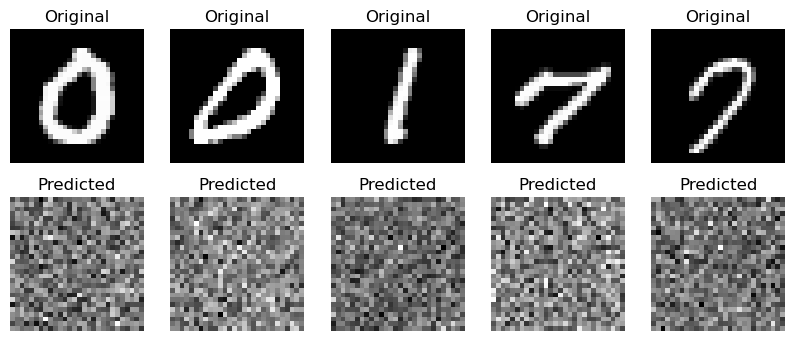

In [182]:
import matplotlib.pyplot as plt

n = 5

plt.figure(figsize=(10,4))

for i in range(n):

    # Original image
    plt.subplot(2, n, i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Predicted / reconstructed image
    plt.subplot(2, n, i+1+n)
    plt.imshow(decoded[i].reshape(28,28), cmap="gray")
    plt.title("Predicted")
    plt.axis("off")

plt.show()

In [183]:
import tensorflow as tf
from tensorflow.keras import layers, Model, losses, optimizers

# 1. & 2. The VAE Class with Reparameterization and Loss Logic
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            # Forward pass through Encoder (returns mean, log_var, and sampled z)
            z_mean, z_log_var, z = self.encoder(data)
            
            # Forward pass through Decoder
            reconstruction = self.decoder(z)

            # Calculate Reconstruction Loss (Binary Crossentropy)
            # We sum over the image dimensions (28, 28)
            r_loss = tf.reduce_mean(
                tf.reduce_sum(losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )

            # Calculate KL Divergence Loss
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

            # Total VAE Loss
            total_loss = r_loss + kl_loss

        # Update model weights using optimizer
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # Output the loss values
        return {
            "loss": total_loss,
            "reconstruction_loss": r_loss,
            "kl_loss": kl_loss,
        }

# --- Initialize and Train ---
vae_model = VAE(encoder, decoder)
vae_model.compile(optimizer=optimizers.Adam(learning_rate=0.001))

# Start training
vae_model.fit(x_train, epochs=20, batch_size=64)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 15.2112 - loss: 195.3398 - reconstruction_loss: 180.1286
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - kl_loss: 16.6584 - loss: 158.5850 - reconstruction_loss: 141.9266
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - kl_loss: 13.4843 - loss: 165.8345 - reconstruction_loss: 152.3502
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - kl_loss: 13.5630 - loss: 161.1327 - reconstruction_loss: 147.5697
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - kl_loss: 13.7626 - loss: 160.7114 - reconstruction_loss: 146.9488
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - kl_loss: 15.5804 - loss: 166.6837 - reconstruction_loss: 151.1033
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - kl_loss: 12.3149 - loss: 178.5195 - reconstruction_loss: 166.2046
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - kl_loss: 17.3033 - loss: 136.2775 - reconstruction_loss: 118.9743
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - kl_l

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


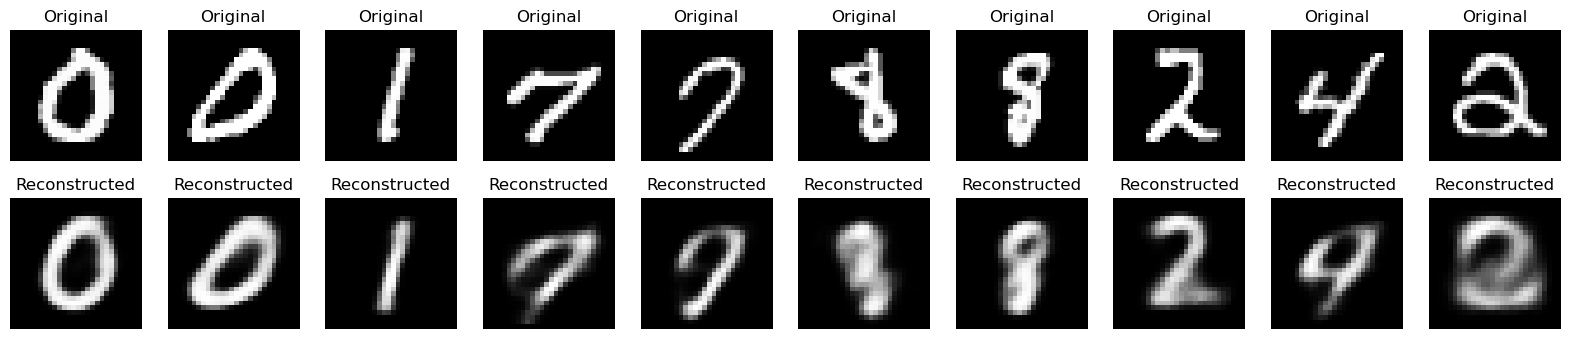

In [184]:
samples = x_train[:10]
z_mean, z_log_var, z = vae_model.encoder.predict(samples)
reconstructions = vae_model.decoder.predict(z)

plt.figure(figsize=(20, 4))
for i in range(10):
    # Display Original
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(samples[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Display Reconstruction
    ax = plt.subplot(2, 10, i + 1 + 10)
    plt.imshow(reconstructions[i].reshape(28, 28), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 910us/step


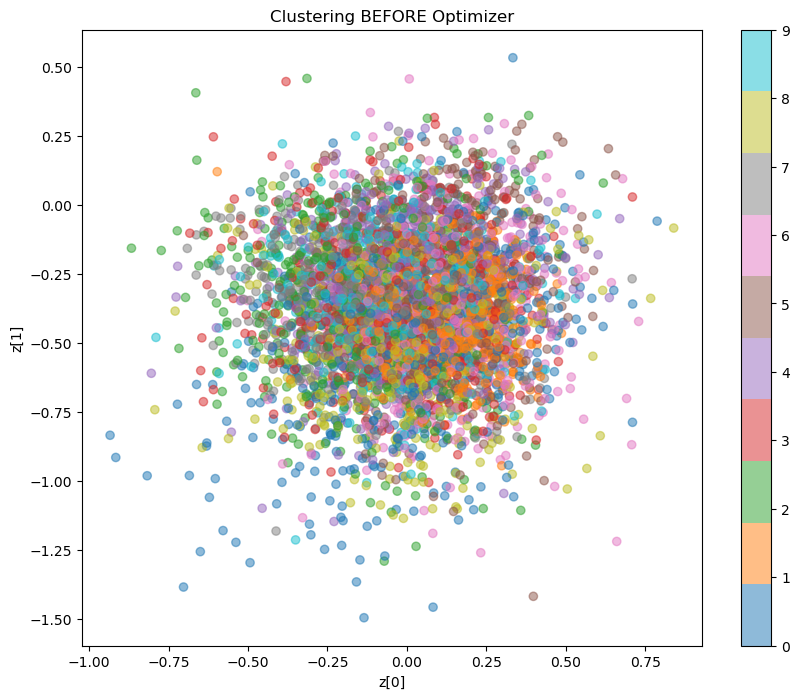

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 939us/step


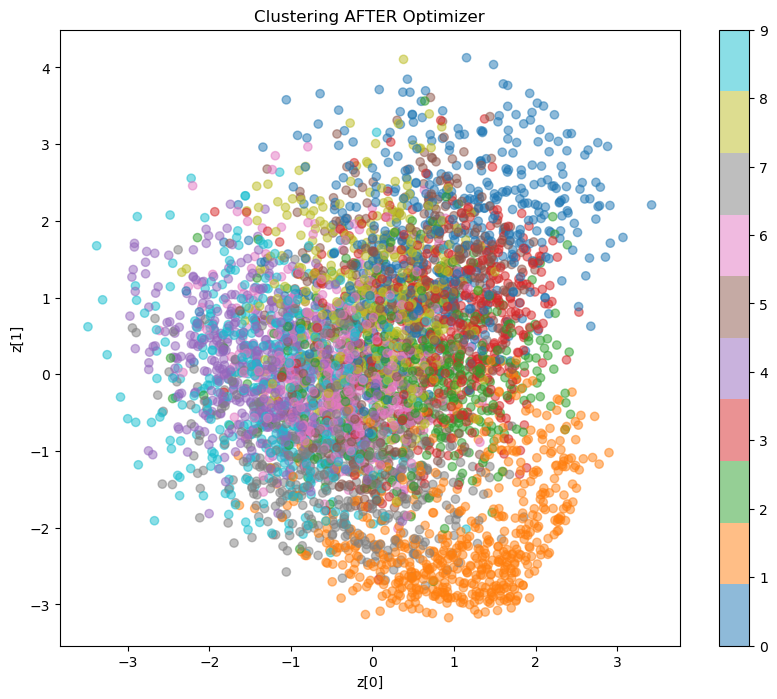

In [181]:
# 1. Get the labels for your training subset
(_, y_train_all), _ = tf.keras.datasets.mnist.load_data()
y_train_labels = y_train_all[idx] # using the 'idx' from your notebook

def plot_clusters(encoder, data, labels, title="Latent Space Clustering"):
    # Get the mean vectors (the center of the distributions)
    z_mean, _, _ = encoder.predict(data)
    
    plt.figure(figsize=(10, 8))
    # Plot only the first two dimensions of your 8D latent space
    plt.scatter(z_mean[:, 0], z_mean[:, 1], c=labels, cmap='tab10', alpha=0.5)
    plt.colorbar()
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.title(title)
    plt.show()

# Run this BEFORE training (on your raw encoder)
plot_clusters(encoder, x_train, y_train_labels, title="Clustering BEFORE Optimizer")

# Run this AFTER training (on your vae_model.encoder)
plot_clusters(vae_model.encoder, x_train, y_train_labels, title="Clustering AFTER Optimizer")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


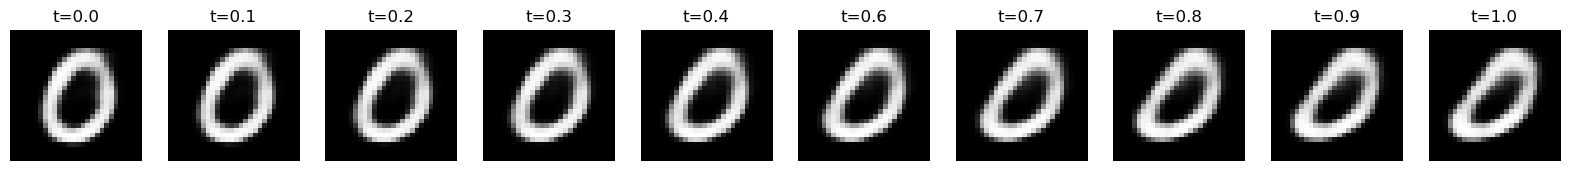

In [186]:
def plot_interpolation(vae, digit_1_idx=0, digit_2_idx=1):
    # Get latent vectors for two real images
    x1 = x_train[digit_1_idx:digit_1_idx+1]
    x2 = x_train[digit_2_idx:digit_2_idx+1]
    
    z1, _, _ = vae.encoder.predict(x1)
    z2, _, _ = vae.encoder.predict(x2)
    
    # Interpolate between the two points
    steps = 10
    plt.figure(figsize=(20, 2))
    for i, t in enumerate(np.linspace(0, 1, steps)):
        z_interp = z1 + (z2 - z1) * t
        reconstruction = vae.decoder.predict(z_interp, verbose=0)
        
        plt.subplot(1, steps, i + 1)
        plt.imshow(reconstruction[0].reshape(28, 28), cmap='gray')
        plt.axis('off')
        plt.title(f"t={t:.1f}")
    plt.show()

plot_interpolation(vae_model)